In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def processSignals(ref, echo, burst_len, num_steps):
    signal_ratio = echo*np.conjugate(ref);
    signal_ratio_reshaped = np.reshape(signal_ratio,[-1,burst_len])
    freq_response = np.mean(signal_ratio_reshaped, axis=1)
    s = freq_response * np.hamming(num_steps)
    s = np.fft.ifft(s)
    return freq_response, s

524288
524288


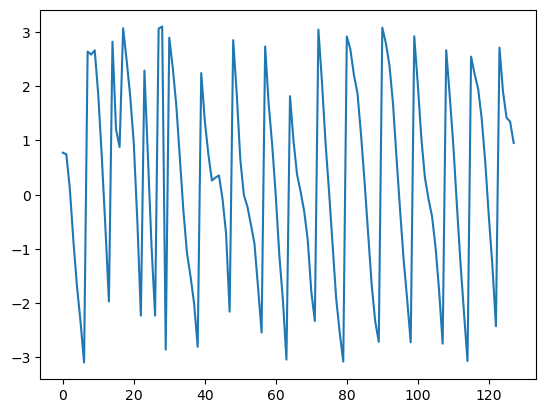

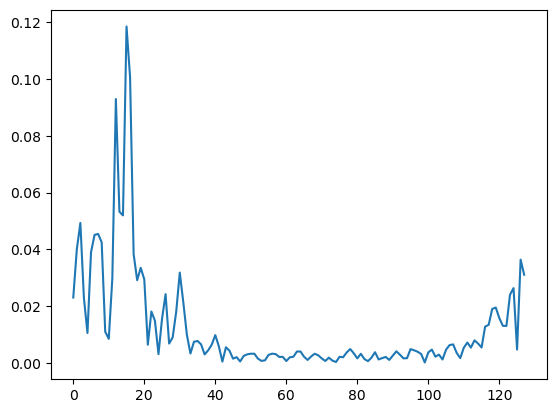

In [14]:
burst_len = 4096
num_steps = 128
supposedSize = burst_len*num_steps
dir = '../gui/'
ref_samples = np.fromfile(dir+'scan_raw_ref_2.dat', np.complex64)
N = supposedSize - ref_samples.size
ref_samples = np.pad(ref_samples,(0,N),'constant')
print(ref_samples.size)
rx_samples = np.fromfile(dir+'scan_raw_rx_2.dat', np.complex64)
N = supposedSize - rx_samples.size
rx_samples = np.pad(rx_samples,(0,N),'constant')
print(rx_samples.size)

f_cal,s_cal = processSignals(ref_samples, rx_samples, burst_len, num_steps)

plt.figure()
plt.plot(np.angle(f_cal))

plt.figure()
#plt.plot(10*np.log10(np.abs(s)))
plt.plot((np.abs(s_cal)))

In [4]:
rx_samples = np.fromfile('file_rx_20.dat', np.complex64) # Read in file.  We have to tell it what format it is
print(rx_samples.size)
plt.plot(np.abs(rx_samples[0:4096]))

plt.figure()
ref_samples = np.fromfile('file_ref_20.dat', np.complex64) # Read in file.  We have to tell it what format it is
print(ref_samples.size)
plt.plot(np.abs(ref_samples[0:4096]))

plt.figure()
calibreated = rx_samples-cal_samples
plt.plot(np.abs(calibreated[0:4096]))

FileNotFoundError: [Errno 2] No such file or directory: 'file_rx_20.dat'

In [5]:
f_calbrated,s_calbrated = processSignals(ref_samples,calibreated,burst_len)
f_rx,s_rx = processSignals(ref_samples,rx_samples,burst_len)

NameError: name 'ref_samples' is not defined

In [6]:
plt.plot(np.angle(f_rx),color='green')
plt.plot(np.angle(f_calbrated))
plt.figure()
# plt.plot(10*np.log10(np.abs(s)),color = 'green')
# plt.plot(10*np.log10(np.abs(s_calbrated)))
plt.plot((np.abs(s_rx)),color = 'green')
plt.plot((np.abs(s_calbrated)))

f_calibrated = f_rx-f_cal
s = f_calibrated
s = np.fft.ifft(s)
plt.plot(np.abs(s))

NameError: name 'f_rx' is not defined

In [9]:
s_list = []
s_cal_list = []
s_cal_list_2 = []
burst_len = 2048
dir = '../gui/'
for i in range(36):
    fileName_rx = dir+'scan_raw_rx_'+str(i)+'.dat'
    fileName_ref = dir+'scan_raw_ref_'+str(i)+'.dat'
    rx_samples = np.fromfile(fileName_rx, np.complex64) # Read in file.  We have to tell it what format it is
    ref_samples = np.fromfile(fileName_ref, np.complex64) # Read in file.  We have to tell it what format it is
    #rx_samples = rx_samples/cal_samples
    f_rx,s_rx = processSignals(ref_samples,rx_samples,burst_len)
    s_list.append(s_rx)
    f_calibrated = f_rx-f_cal
    s = f_calibrated
    s = np.fft.ifft(s)
    s_cal_list.append(s)
    s_cal_list_2.append(s-s_cal)
s_np = np.stack(s_list, axis=0)
s_cal_np = np.stack(s_cal_list, axis = 0)
s_cal_np_2 =  np.stack(s_cal_list_2, axis = 0)

ValueError: cannot reshape array of size 262080 into shape (2048)

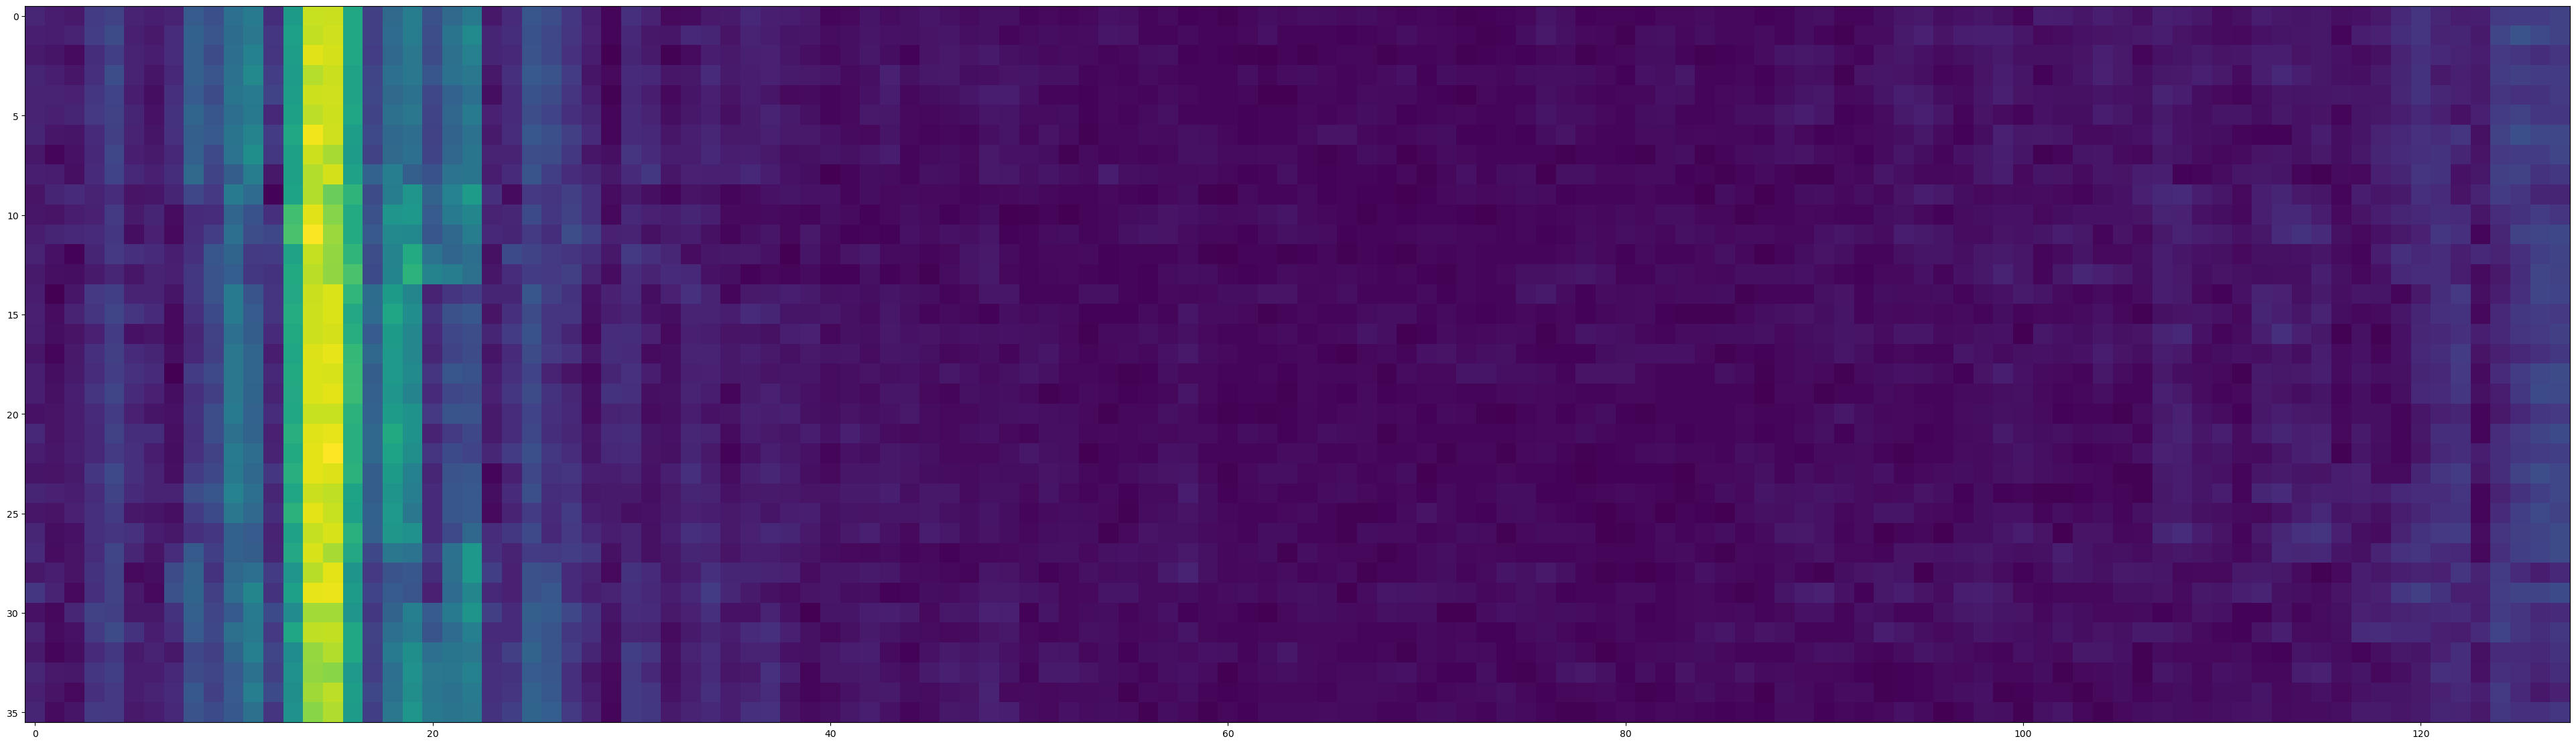

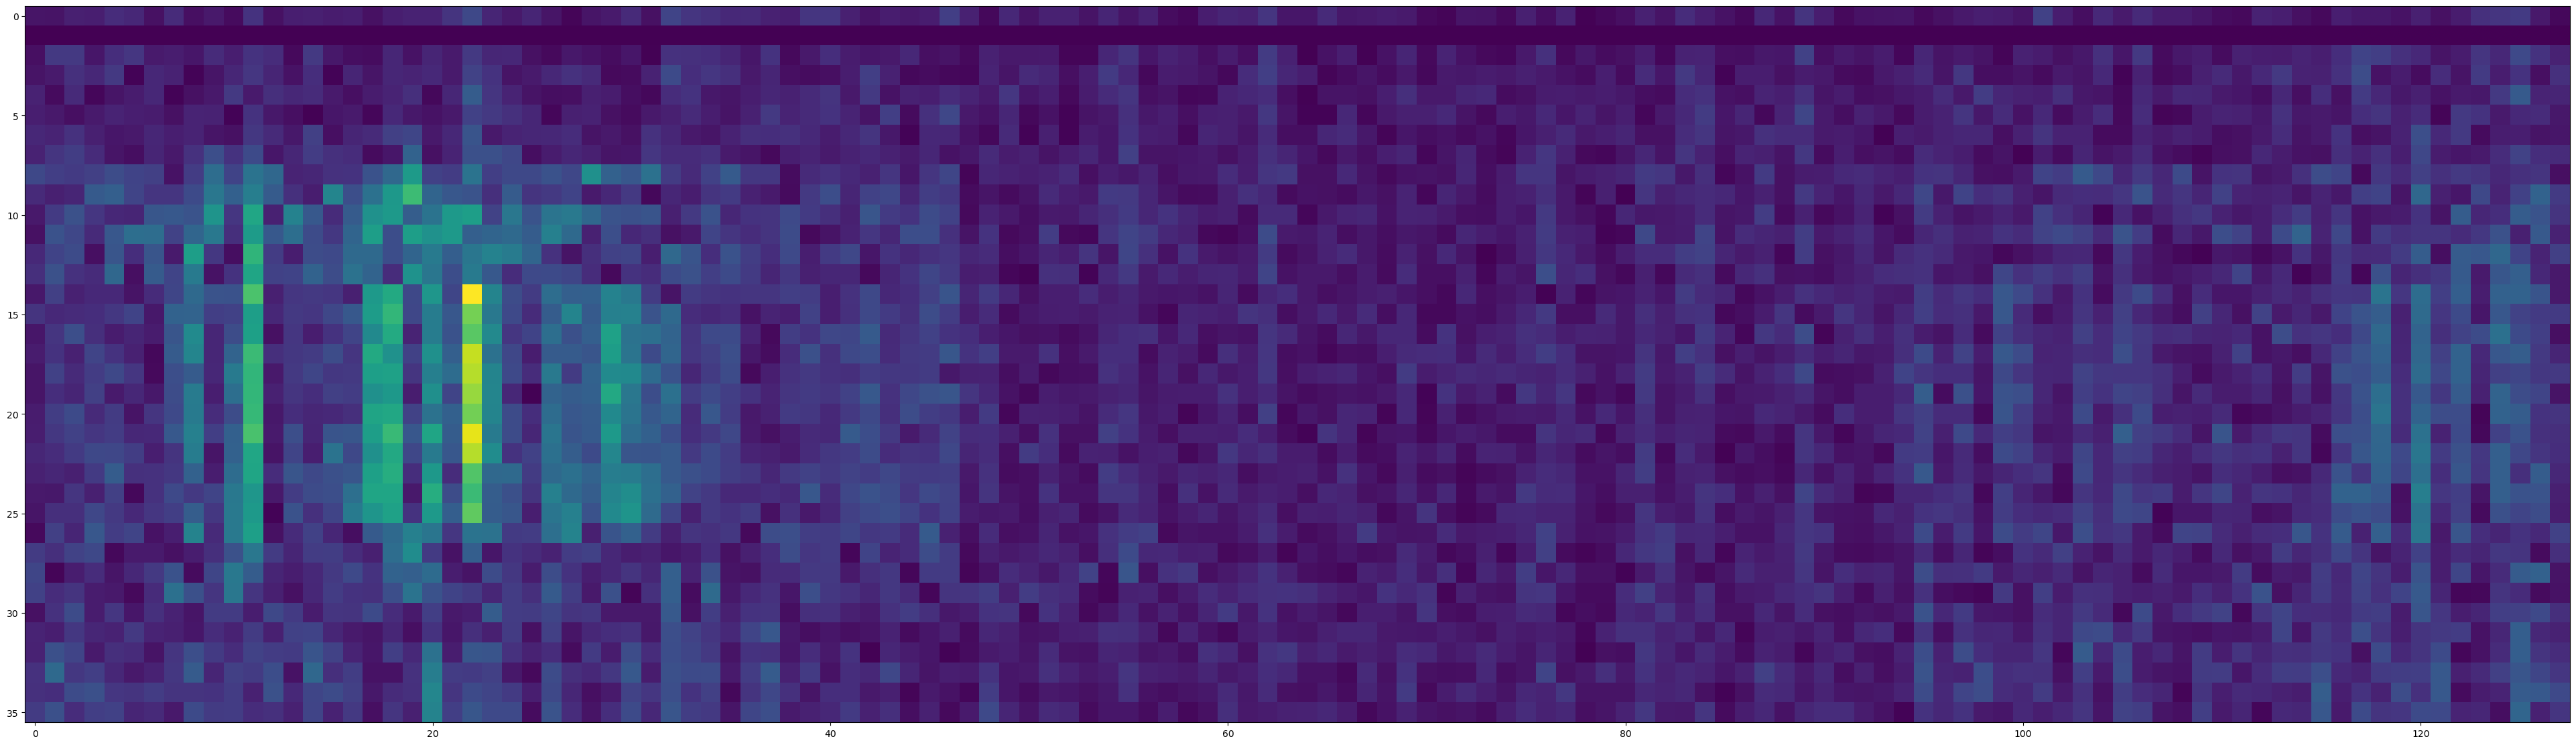

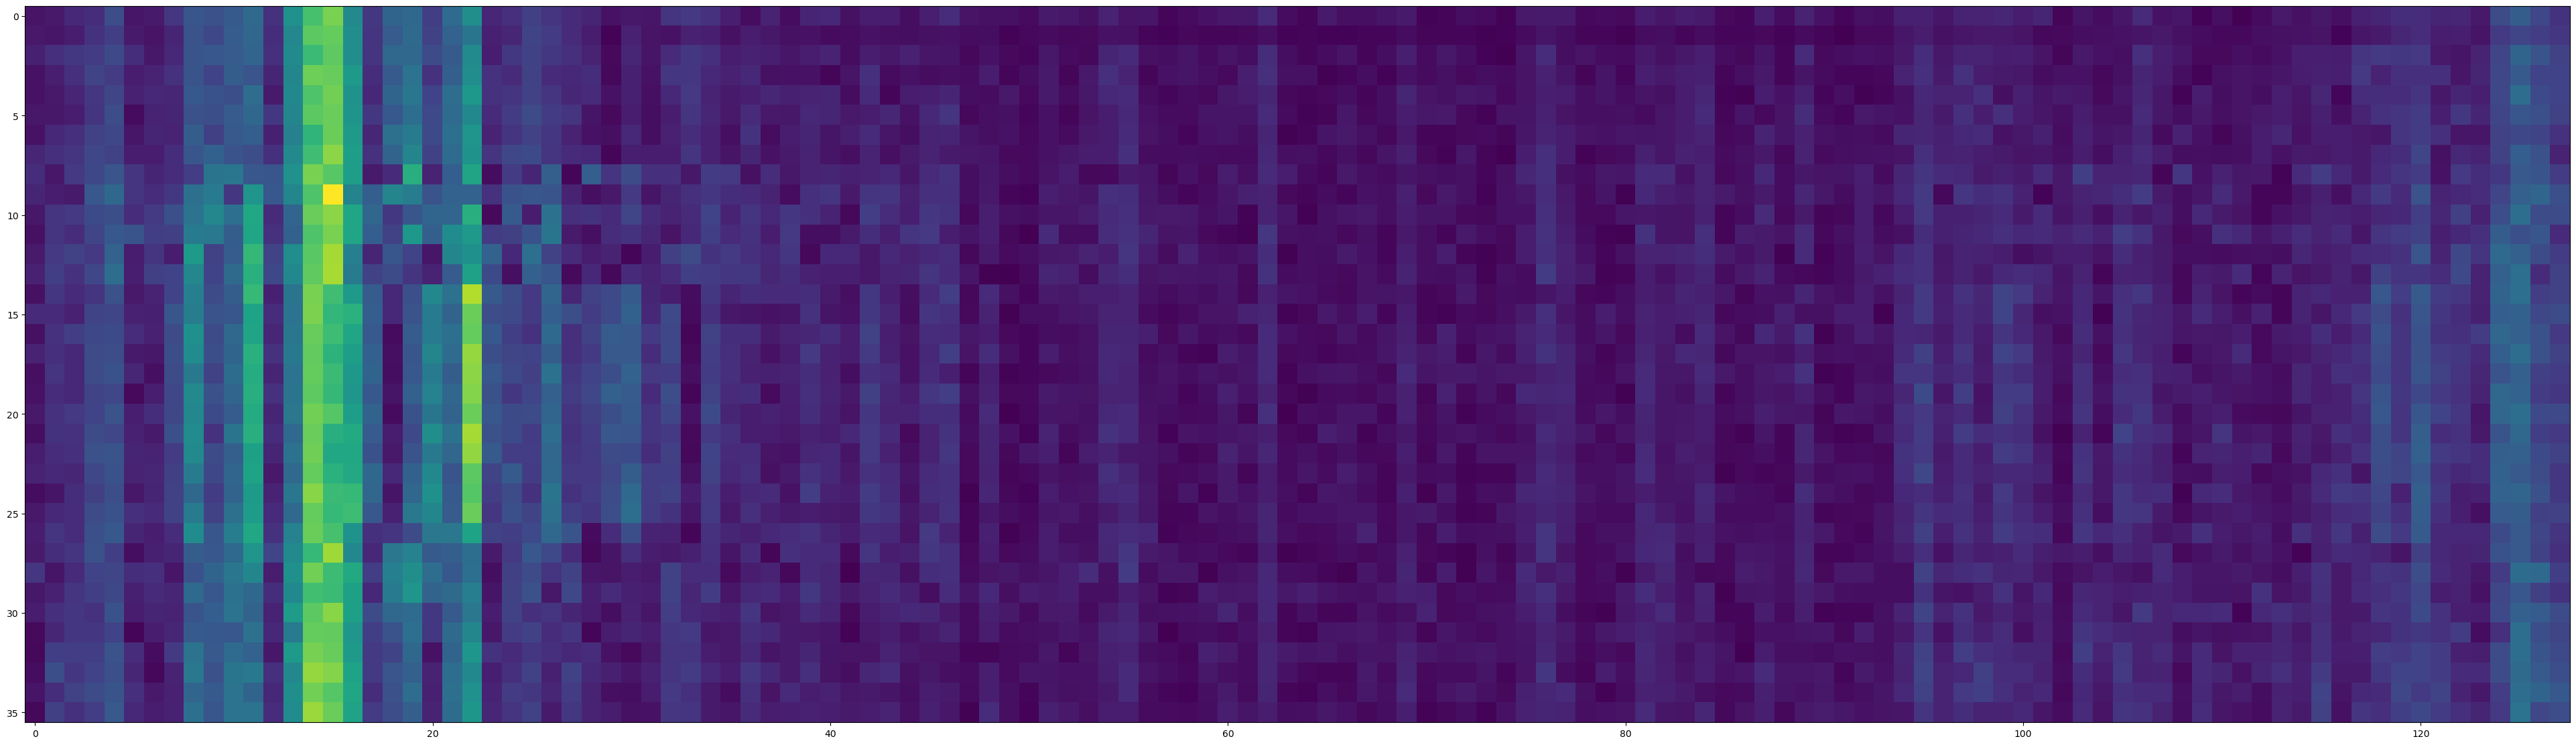

In [86]:
plt.figure(figsize=[49,20])
plt.imshow(np.abs(s_np))

plt.figure(figsize=[49,20])
plt.imshow(np.abs(s_cal_np))

plt.figure(figsize=[49,20])
plt.imshow(np.abs(s_cal_np_2))

In [28]:
s_list = []
for i in range(6):
    fileName_rx = 'file_rx_'+str(i)+'.dat'
    fileName_ref = 'file_rx_'+str(i)+'.dat'
    rx_samples = np.fromfile('file_rx_5.dat', np.complex64) # Read in file.  We have to tell it what format it is
    ref_samples = np.fromfile('file_ref_5.dat', np.complex64) # Read in file.  We have to tell it what format it is
    f_rx,s_rx = processSignals(ref_samples,rx_samples,burst_len)
    f_calibrated = f_rx-f_cal
    s = f_calibrated
    s = np.fft.ifft(s)
    s_list.append(s)
s_np = np.stack(s_list, axis=0)

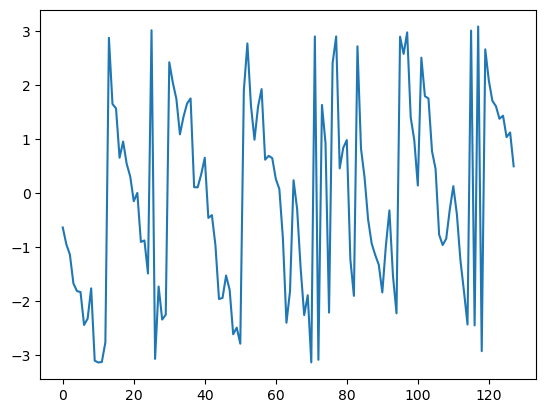

In [29]:
plt.plot(np.angle(phase_diff_mean))

In [30]:
s = np.fft.ifft(phase_diff_mean)

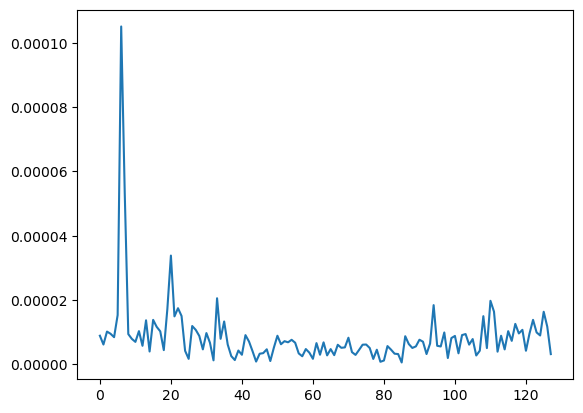

In [31]:
plt.plot(np.abs(s))